In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
shap.initjs()
print('环境加载完成')

/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


环境加载完成


In [3]:
base_dir = Path('/Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8')
output_dir = base_dir / 'final_3.8_pic_outputs'
output_dir.mkdir(exist_ok=True)

new_file = base_dir / 'Final_Features_3.8.csv'
old_file = Path('/Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_1.9/Final_Features_Ultimate_all_deletion.csv')

df_new = pd.read_csv(new_file)
df_old = pd.read_csv(old_file)

features_mech = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]
features_heal = features_mech + ['healing_temperature', 'healing_time']

old_heal_features = [
    'X1_Soft_Content',
    'X2_DA_Content',
    'X3_Hard_Content',
    'X4_R_Ratio',
    'X5_Add_Crosslink',
    'DA_Linker_Type',
    'Network_Topology',
    'Add_Crosslinker_Flag',
    'Polyol_Class',
    'Iso_Class',
    'Extender_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
    'healing_temperature',
    'healing_time',
]

old_heal_valid = df_old.dropna(subset=['healing_eff'] + old_heal_features).copy()
old_heal_ids = sorted(old_heal_valid['sample_id'].unique().tolist())
new_heal_valid = df_new.dropna(subset=['healing_eff'] + features_heal).copy()
extra_heal_ids = sorted(set(new_heal_valid['sample_id']) - set(old_heal_ids))

target_configs = {
    'tensile_strength': {
        'feature_cols': features_mech,
        'data': df_new.copy(),
        'subset_name': 'CurrentFull84',
    },
    'elongation': {
        'feature_cols': features_mech,
        'data': df_new.copy(),
        'subset_name': 'CurrentFull84',
    },
    'healing_eff': {
        'feature_cols': features_heal,
        'data': df_new[df_new['sample_id'].isin(old_heal_ids)].copy(),
        'subset_name': 'AlignedOld37',
    },
}

print('数据读取完成')
print(f'当前 3.8 总样本数: {len(df_new)}')
print(f'旧版 healing 对齐样本数: {len(old_heal_ids)}')
print(f'排除的新增 healing 样本数: {len(extra_heal_ids)}')
print('排除样本 ID:', extra_heal_ids)

数据读取完成
当前 3.8 总样本数: 85
旧版 healing 对齐样本数: 37
排除的新增 healing 样本数: 8
排除样本 ID: ['BQDU-CPU', 'C-DAPU-C%-3', 'DA-PU-BMImain_chain-100', 'DA-SM-PU-3', 'PU-BDO-A', 'PU-DA-PPG-R2.0-SiO2纳米3', 'PU-DA-PPG-R2.0-hard2', 'PU-DA-PPG-R2.5']


In [4]:
loo = LeaveOneOut()

base_models = {
    'MLR': LinearRegression(),
    'Ridge': make_pipeline(StandardScaler(), Ridge(random_state=42)),
    'LASSO': make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=1),
    'GPR': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42,
        ),
    ),
    'MLP': make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000)),
}

param_spaces = {
    'MLR': {},
    'Ridge': {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'LASSO': {'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]},
    'SVR': {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    },
    'Random Forest': {
        'n_estimators': [300, 600, 800],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 0.7],
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.02, 0.05],
        'max_depth': [3, 4, 6],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
        'reg_alpha': [0.0, 1.0],
        'reg_lambda': [1.0, 5.0],
    },
    'GPR': {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10],
    },
    'MLP': {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (64, 32)],
        'mlpregressor__activation': ['tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001],
    },
}

def strict_tune_and_predict(model_name, model, param_space, X, y):
    if param_space:
        search = GridSearchCV(
            estimator=model,
            param_grid=param_space,
            cv=loo,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
        )
        search.fit(X, y)
        best_model = search.best_estimator_
        best_params = search.best_params_
        route = 'StrictGridSearch+LOOCV'
    else:
        best_model = model.fit(X, y)
        best_params = {}
        route = 'Default(NoTune)+LOOCV'

    y_pred = cross_val_predict(best_model, X, y, cv=loo, n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    best_model.fit(X, y)
    return {
        'best_model': best_model,
        'best_params': best_params,
        'route': route,
        'r2': r2,
        'rmse': rmse,
        'y_pred': y_pred,
    }

all_rows = []
best_rows = []
best_model_store = {}

for target_name, cfg in target_configs.items():
    data = cfg['data'].dropna(subset=[target_name] + cfg['feature_cols']).copy()
    X = data[cfg['feature_cols']]
    y = data[target_name]
    print('\n' + '=' * 110)
    print(f'目标: {target_name} | 样本口径: {cfg["subset_name"]} | 样本数: {len(y)} | 特征数: {len(cfg["feature_cols"])}')
    print('=' * 110)

    target_rows = []
    for model_name, model in base_models.items():
        res = strict_tune_and_predict(model_name, model, param_spaces[model_name], X, y)
        row = {
            'Target': target_name,
            'Subset': cfg['subset_name'],
            'Model': model_name,
            'R2': res['r2'],
            'RMSE': res['rmse'],
            'Samples': len(y),
            'Feature_Count': len(cfg['feature_cols']),
            'Best_Params': str(res['best_params']),
            'Route': res['route'],
        }
        all_rows.append(row)
        target_rows.append(row)
        best_model_store[(target_name, model_name)] = {
            'model': res['best_model'],
            'X': X.copy(),
            'y': y.copy(),
            'y_pred': pd.Series(res['y_pred'], index=y.index),
            'feature_cols': cfg['feature_cols'],
            'subset_name': cfg['subset_name'],
        }
        print(f" -> {model_name}: R²={res['r2']:.4f}, RMSE={res['rmse']:.4f}")

    target_df = pd.DataFrame(target_rows).sort_values('R2', ascending=False).reset_index(drop=True)
    display(target_df[['Target', 'Subset', 'Model', 'R2', 'RMSE', 'Samples', 'Feature_Count']])
    best_rows.append(target_df.iloc[0].to_dict())

result_table = pd.DataFrame(all_rows).sort_values(['Target', 'R2'], ascending=[True, False]).reset_index(drop=True)
best_model_table = pd.DataFrame(best_rows).sort_values('Target').reset_index(drop=True)

result_table.to_csv(output_dir / 'three_target_strict_model_results.csv', index=False, encoding='utf-8-sig')
best_model_table.to_csv(output_dir / 'three_target_best_models.csv', index=False, encoding='utf-8-sig')

print('\n完整结果表已保存到: ', output_dir / 'three_target_strict_model_results.csv')
print('最优模型汇总已保存到: ', output_dir / 'three_target_best_models.csv')
display(best_model_table[['Target', 'Subset', 'Model', 'R2', 'RMSE', 'Samples', 'Feature_Count']])


目标: tensile_strength | 样本口径: CurrentFull84 | 样本数: 84 | 特征数: 15
 -> MLR: R²=-7.5288, RMSE=39.2715
 -> Ridge: R²=0.6535, RMSE=7.9159
 -> LASSO: R²=0.6484, RMSE=7.9733
 -> SVR: R²=0.7581, RMSE=6.6132
 -> Random Forest: R²=0.6795, RMSE=7.6128
 -> XGBoost: R²=0.6816, RMSE=7.5879
 -> GPR: R²=0.7119, RMSE=7.2184


KeyboardInterrupt: 

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

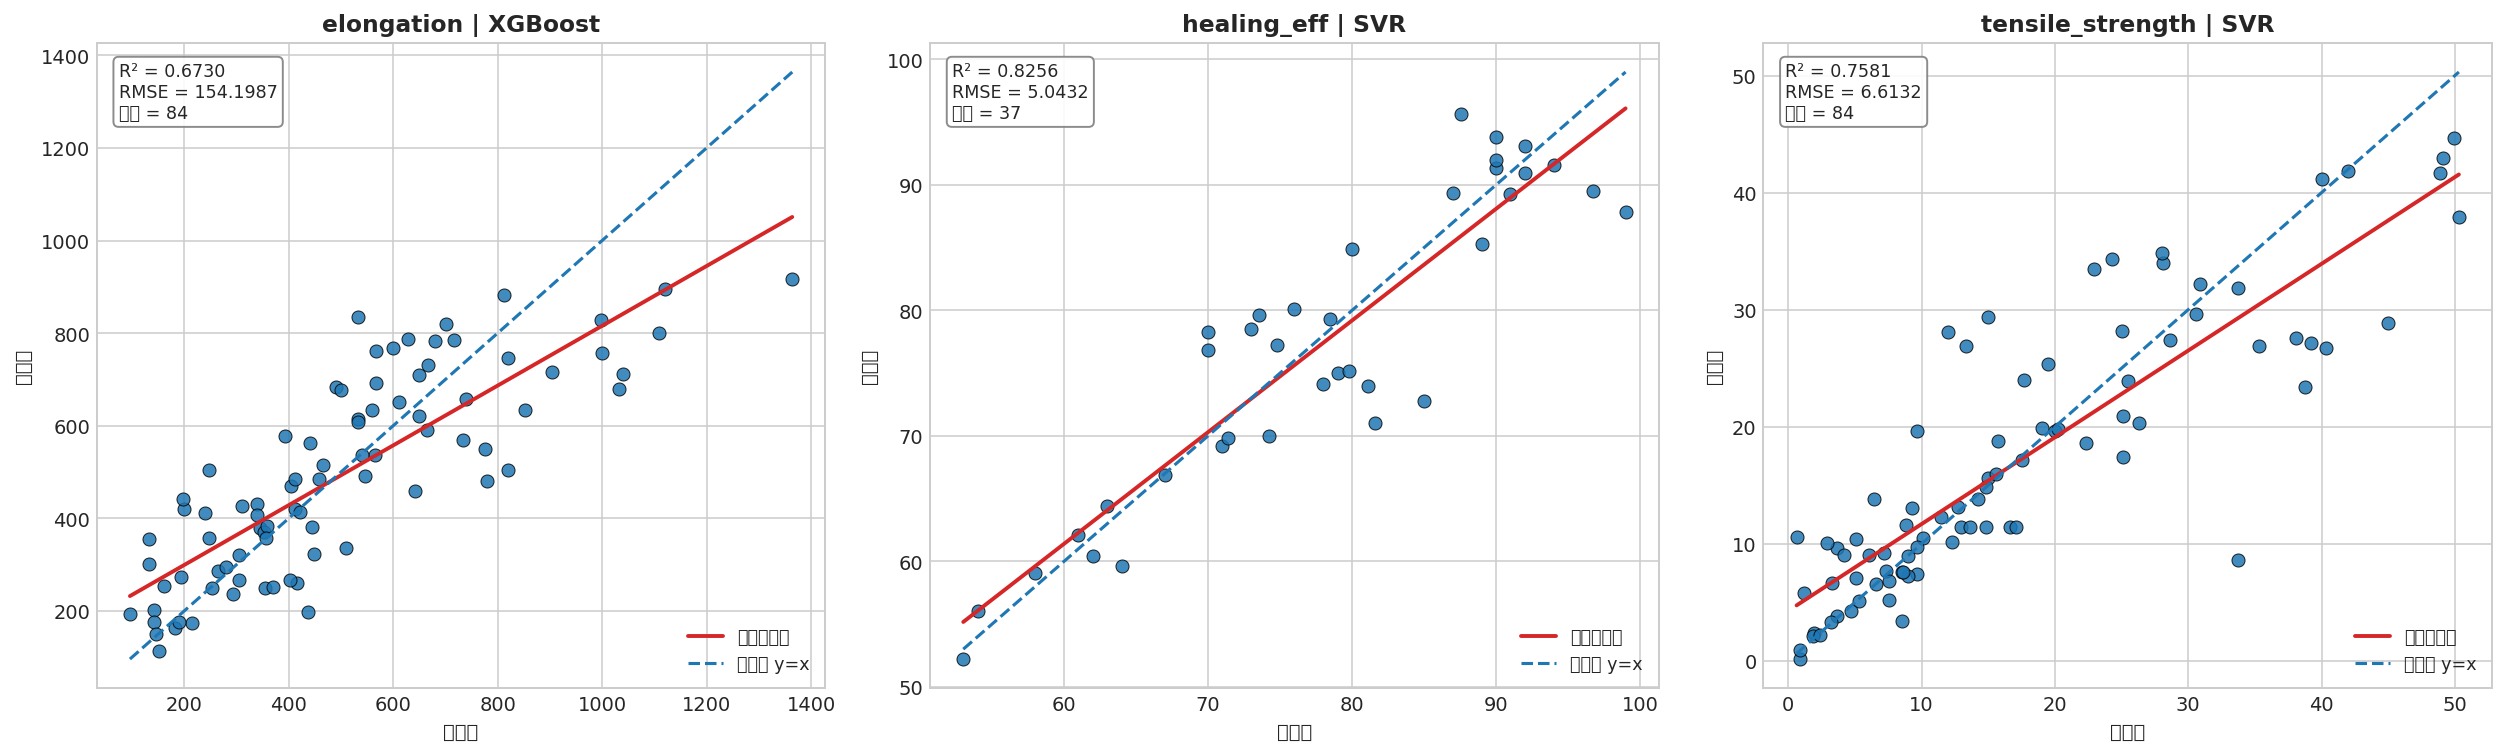

线性回归图已保存到:  /Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8/final_3.8_pic_outputs/three_target_best_model_regression.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=140)

for idx, row in best_model_table.iterrows():
    target_name = row['Target']
    model_name = row['Model']
    store = best_model_store[(target_name, model_name)]
    y_true = store['y']
    y_pred = store['y_pred']
    ax = axes[idx]

    ax.scatter(y_true, y_pred, s=45, alpha=0.85, edgecolors='black', linewidths=0.5)

    coef = np.polyfit(y_true, y_pred, deg=1)
    x_line = np.linspace(y_true.min(), y_true.max(), 100)
    y_line = coef[0] * x_line + coef[1]
    ax.plot(x_line, y_line, color='#D62728', linewidth=2, label='线性回归线')
    ax.plot(x_line, x_line, color='#1F77B4', linestyle='--', linewidth=1.6, label='理想线 y=x')

    ax.set_title(f'{target_name} | {model_name}', fontweight='bold')
    ax.set_xlabel('实验值')
    ax.set_ylabel('预测值')
    ax.legend(fontsize=9)
    ax.text(
        0.03, 0.97,
        f'R² = {row["R2"]:.4f}\nRMSE = {row["RMSE"]:.4f}\n样本 = {int(row["Samples"])}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9),
    )

plt.tight_layout()
reg_path = output_dir / 'three_target_best_model_regression.png'
plt.show()
print('线性回归图已保存到: ', reg_path)

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

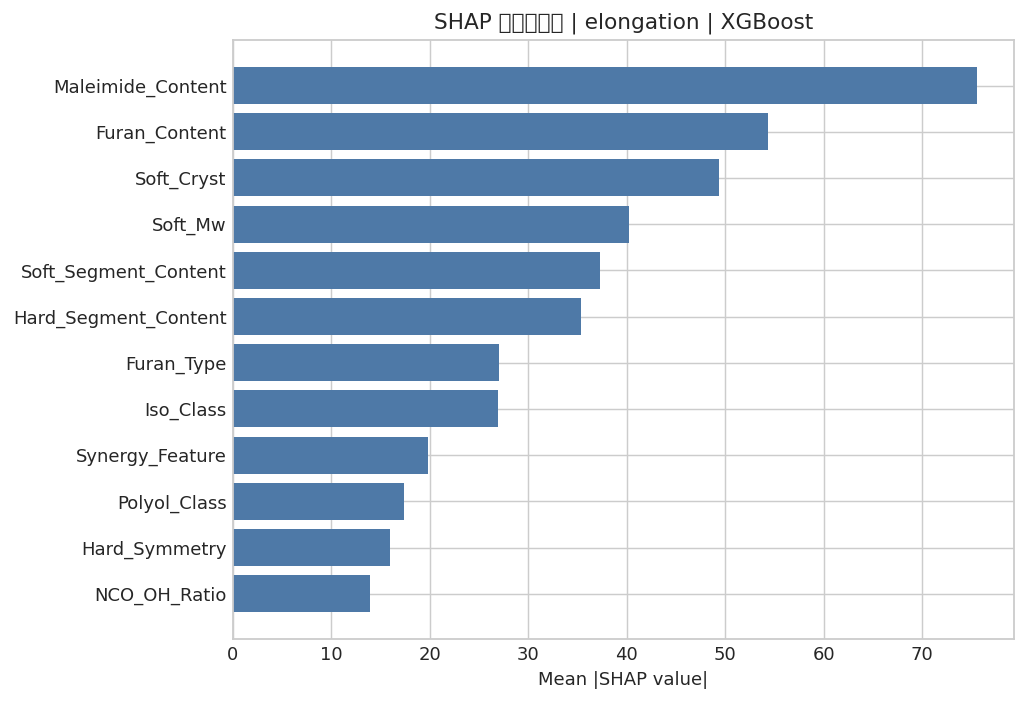

elongation 的 SHAP 结果已保存到: /Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8/final_3.8_pic_outputs/shap_importance_elongation.csv


100%|██████████| 37/37 [00:00<00:00, 134.83it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimH

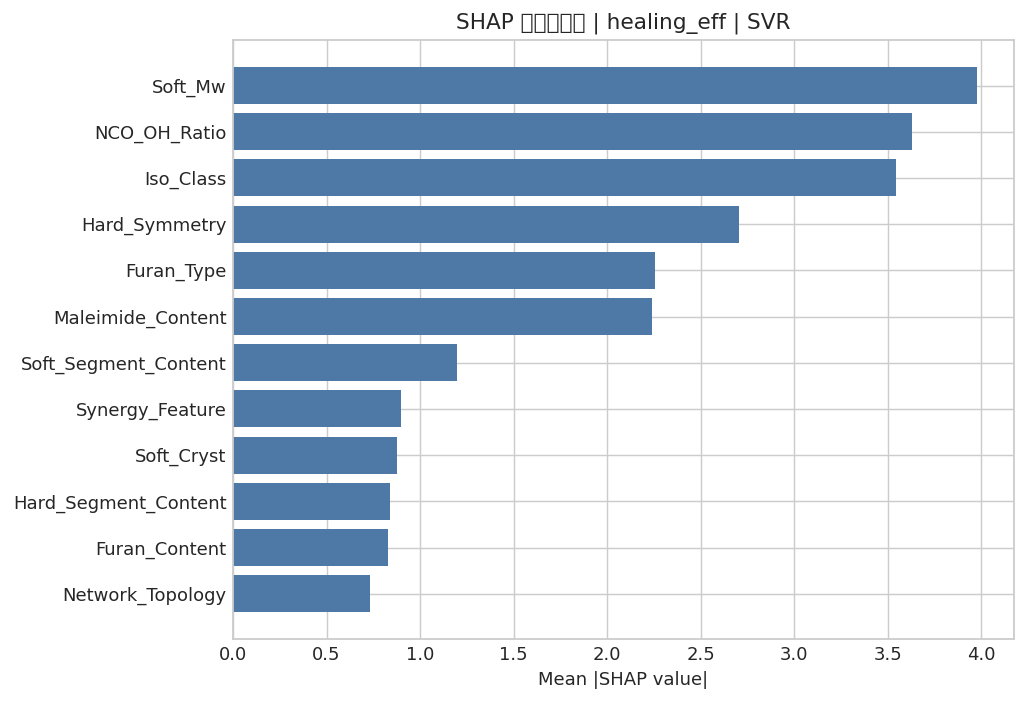

healing_eff 的 SHAP 结果已保存到: /Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8/final_3.8_pic_outputs/shap_importance_healing_eff.csv


100%|██████████| 40/40 [00:00<00:00, 116.92it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimH

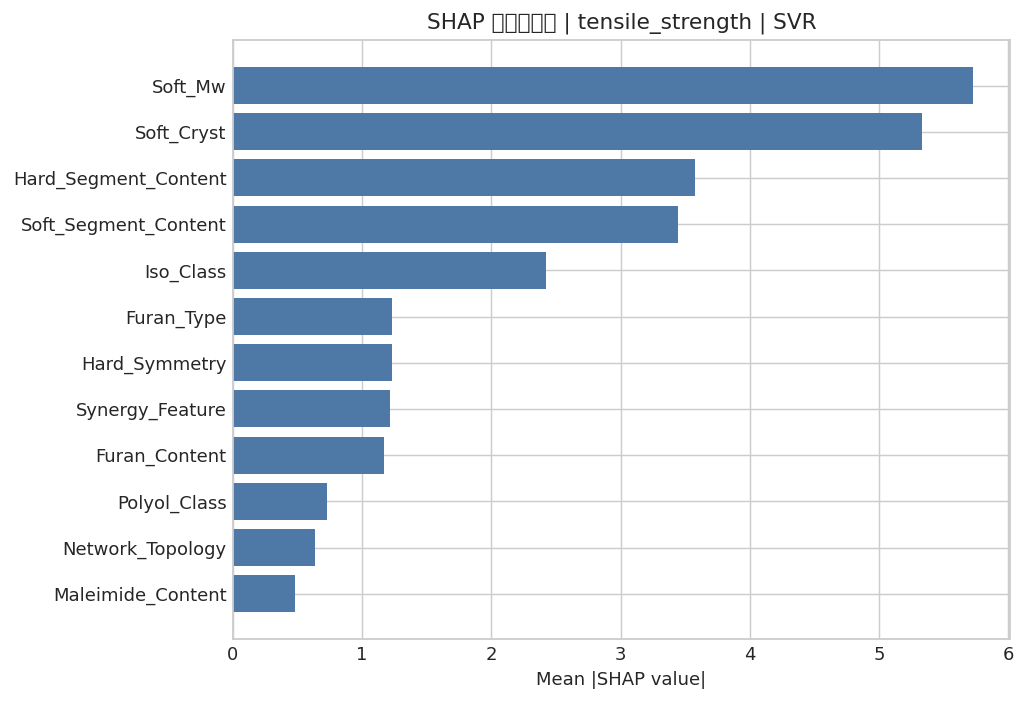

tensile_strength 的 SHAP 结果已保存到: /Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8/final_3.8_pic_outputs/shap_importance_tensile_strength.csv


,Target,Best_Model,Top1_Feature,Top1_SHAP,Top2_Feature,Top2_SHAP,Top3_Feature,Top3_SHAP,CSV_Path,PNG_Path
0,elongation,XGBoost,Maleimide_Content,75.550430,Furan_Content,54.300423,Soft_Cryst,49.371616,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...
1,healing_eff,SVR,Soft_Mw,3.975220,NCO_OH_Ratio,3.626435,Iso_Class,3.543780,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...
2,tensile_strength,SVR,Soft_Mw,5.724531,Soft_Cryst,5.333312,Hard_Segment_Content,3.571615,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...,/Users/yljj0528/Documents/GitHub/ML_DAPU/forec...


In [ ]:
def get_final_estimator(model):
    if hasattr(model, 'named_steps'):
        return list(model.named_steps.values())[-1]
    return model

def compute_shap_importance(model_name, model, X_df, target_name):
    final_estimator = get_final_estimator(model)
    explain_X = X_df.copy()

    if model_name in ['XGBoost', 'Random Forest']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(explain_X)
    else:
        background = shap.sample(explain_X, min(20, len(explain_X)), random_state=42)
        explain_sample = shap.sample(explain_X, min(40, len(explain_X)), random_state=42)

        def predict_fn(data_array):
            data_df = pd.DataFrame(data_array, columns=explain_X.columns)
            return model.predict(data_df)

        explainer = shap.KernelExplainer(predict_fn, background)
        shap_values = explainer.shap_values(explain_sample, nsamples=120)
        explain_X = explain_sample

    shap_array = np.array(shap_values)
    if shap_array.ndim == 3:
        shap_array = shap_array[0]

    importance_df = pd.DataFrame({
        'Feature': explain_X.columns,
        'MeanAbsSHAP': np.abs(shap_array).mean(axis=0),
    }).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

    csv_path = output_dir / f'shap_importance_{target_name}.csv'
    importance_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

    plt.figure(figsize=(8, 5.5), dpi=130)
    top_df = importance_df.head(12).iloc[::-1]
    plt.barh(top_df['Feature'], top_df['MeanAbsSHAP'], color='#4E79A7')
    plt.xlabel('Mean |SHAP value|')
    plt.title(f'SHAP 特征重要性 | {target_name} | {model_name}')
    plt.tight_layout()
    png_path = output_dir / f'shap_importance_{target_name}.png'
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.show()

    return importance_df, csv_path, png_path

shap_summary_rows = []
for _, row in best_model_table.iterrows():
    target_name = row['Target']
    model_name = row['Model']
    store = best_model_store[(target_name, model_name)]
    importance_df, csv_path, png_path = compute_shap_importance(model_name, store['model'], store['X'], target_name)
    shap_summary_rows.append({
        'Target': target_name,
        'Best_Model': model_name,
        'Top1_Feature': importance_df.iloc[0]['Feature'],
        'Top1_SHAP': importance_df.iloc[0]['MeanAbsSHAP'],
        'Top2_Feature': importance_df.iloc[1]['Feature'] if len(importance_df) > 1 else None,
        'Top2_SHAP': importance_df.iloc[1]['MeanAbsSHAP'] if len(importance_df) > 1 else None,
        'Top3_Feature': importance_df.iloc[2]['Feature'] if len(importance_df) > 2 else None,
        'Top3_SHAP': importance_df.iloc[2]['MeanAbsSHAP'] if len(importance_df) > 2 else None,
        'CSV_Path': str(csv_path),
        'PNG_Path': str(png_path),
    })
    print(f'{target_name} 的 SHAP 结果已保存到: {csv_path}')

shap_summary_df = pd.DataFrame(shap_summary_rows)
shap_summary_df.to_csv(output_dir / 'three_target_shap_summary.csv', index=False, encoding='utf-8-sig')
display(shap_summary_df)

## 输出文件清单

本 notebook 会在 `forecast_ML_3.8/final_3.8_pic_outputs/` 下生成：

- `three_target_strict_model_results.csv`：三项目标完整模型结果表
- `three_target_best_models.csv`：三项目标最优模型汇总表
- `three_target_best_model_regression.png`：三项目标最优模型回归图
- `shap_importance_tensile_strength.csv/.png`
- `shap_importance_elongation.csv/.png`
- `shap_importance_healing_eff.csv/.png`
- `three_target_shap_summary.csv`：SHAP 总结表

In [ ]:
from sklearn.neighbors import NearestNeighbors

rng = np.random.default_rng(42)

continuous_mech_cols = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Soft_Mw',
    'Constraint_Factor',
    'Synergy_Feature',
]
cat_mech_cols = [
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Hard_Symmetry',
    'Soft_Cryst',
]
process_cols = ['healing_temperature', 'healing_time']

mech_seed = df_new.dropna(subset=features_mech).copy().reset_index(drop=True)
heal_seed = target_configs['healing_eff']['data'].dropna(subset=features_heal + ['tensile_strength', 'elongation', 'healing_eff']).copy().reset_index(drop=True)

n_candidates = 55000
seed_idx = rng.integers(0, len(mech_seed), size=n_candidates)
candidate_space = mech_seed.loc[seed_idx, features_mech].reset_index(drop=True).copy()

for col in continuous_mech_cols:
    std_val = float(mech_seed[col].std()) if pd.notna(mech_seed[col].std()) else 0.0
    q05 = float(mech_seed[col].quantile(0.05))
    q95 = float(mech_seed[col].quantile(0.95))
    noise = rng.normal(0, 0.25 * std_val if std_val > 0 else 0.0, size=n_candidates)
    candidate_space[col] = np.clip(candidate_space[col].to_numpy() + noise, q05, q95)

for col in cat_mech_cols:
    values = sorted(mech_seed[col].dropna().unique().tolist())
    mutate_mask = rng.random(n_candidates) < 0.35
    if values:
        candidate_space.loc[mutate_mask, col] = rng.choice(values, size=int(mutate_mask.sum()), replace=True)

proc_idx = rng.integers(0, len(heal_seed), size=n_candidates)
for col in process_cols:
    sampled = heal_seed.loc[proc_idx, col].reset_index(drop=True)
    unique_count = heal_seed[col].nunique(dropna=True)
    if unique_count > 10:
        std_val = float(heal_seed[col].std()) if pd.notna(heal_seed[col].std()) else 0.0
        q05 = float(heal_seed[col].quantile(0.05))
        q95 = float(heal_seed[col].quantile(0.95))
        noise = rng.normal(0, 0.15 * std_val if std_val > 0 else 0.0, size=n_candidates)
        candidate_space[col] = np.clip(sampled.to_numpy() + noise, q05, q95)
    else:
        candidate_space[col] = sampled.to_numpy()

for col in cat_mech_cols + process_cols:
    if np.allclose(candidate_space[col].dropna() % 1, 0):
        candidate_space[col] = candidate_space[col].round().astype(int)

candidate_space = candidate_space.drop_duplicates().reset_index(drop=True)

best_model_lookup = {row['Target']: row['Model'] for _, row in best_model_table.iterrows()}
for target_name in ['tensile_strength', 'elongation', 'healing_eff']:
    best_model_name = best_model_lookup[target_name]
    store = best_model_store[(target_name, best_model_name)]
    feature_cols = store['feature_cols']
    candidate_space[f'pred_{target_name}'] = store['model'].predict(candidate_space[feature_cols])

observed_compare = heal_seed[[
    'sample_id',
    'tensile_strength',
    'elongation',
    'healing_eff',
] + features_heal].copy()

candidate_space['Candidate_ID'] = [f'Virtual_{idx + 1:05d}' for idx in range(len(candidate_space))]


def pareto_mask_max(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values)
    is_efficient = np.arange(values.shape[0])
    n_points = values.shape[0]
    next_point_index = 0
    while next_point_index < len(values):
        nondominated_mask = np.any(values > values[next_point_index], axis=1) | np.all(values == values[next_point_index], axis=1)
        nondominated_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_mask]
        values = values[nondominated_mask]
        next_point_index = np.sum(nondominated_mask[:next_point_index]) + 1
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

three_obj_values = candidate_space[['pred_tensile_strength', 'pred_healing_eff', 'pred_elongation']].to_numpy()
candidate_space['is_pareto_3obj'] = pareto_mask_max(three_obj_values)
pareto_3obj_df = candidate_space[candidate_space['is_pareto_3obj']].copy().reset_index(drop=True)

obs_2d = observed_compare[['sample_id', 'tensile_strength', 'healing_eff', 'elongation']].rename(columns={
    'sample_id': 'ID',
    'tensile_strength': 'Tensile',
    'healing_eff': 'Healing',
    'elongation': 'Elongation',
}).copy()
obs_2d['Source'] = 'Observed'
obs_2d['Candidate_ID'] = obs_2d['ID']

pred_2d = pareto_3obj_df[['Candidate_ID', 'pred_tensile_strength', 'pred_healing_eff', 'pred_elongation']].rename(columns={
    'pred_tensile_strength': 'Tensile',
    'pred_healing_eff': 'Healing',
    'pred_elongation': 'Elongation',
}).copy()
pred_2d['Source'] = 'PredictedPareto3Obj'

combined_2d = pd.concat([obs_2d[['Candidate_ID', 'Tensile', 'Healing', 'Elongation', 'Source']], pred_2d[['Candidate_ID', 'Tensile', 'Healing', 'Elongation', 'Source']]], ignore_index=True)
combined_2d['is_pareto_2d_union'] = pareto_mask_max(combined_2d[['Tensile', 'Healing']].to_numpy())

tradeoff_break_df = combined_2d[(combined_2d['Source'] == 'PredictedPareto3Obj') & (combined_2d['is_pareto_2d_union'])].copy().reset_index(drop=True)
tradeoff_break_df = tradeoff_break_df.merge(
    pareto_3obj_df,
    on='Candidate_ID',
    how='left',
)

norm_cols = ['pred_tensile_strength', 'pred_healing_eff', 'pred_elongation']
for col in norm_cols:
    col_min = pareto_3obj_df[col].min()
    col_max = pareto_3obj_df[col].max()
    if col_max > col_min:
        tradeoff_break_df[f'norm_{col}'] = (tradeoff_break_df[col] - col_min) / (col_max - col_min)
    else:
        tradeoff_break_df[f'norm_{col}'] = 1.0

tradeoff_break_df['Balance_Score'] = tradeoff_break_df[[
    'norm_pred_tensile_strength',
    'norm_pred_healing_eff',
    'norm_pred_elongation',
]].mean(axis=1)
tradeoff_break_df['Ideal_Distance'] = np.sqrt(
    (1 - tradeoff_break_df['norm_pred_tensile_strength']) ** 2
    + (1 - tradeoff_break_df['norm_pred_healing_eff']) ** 2
    + (1 - tradeoff_break_df['norm_pred_elongation']) ** 2
)

nn_features = features_heal.copy()
scaler_nn = StandardScaler()
X_ref = scaler_nn.fit_transform(heal_seed[nn_features])
X_cand = scaler_nn.transform(tradeoff_break_df[nn_features]) if len(tradeoff_break_df) > 0 else np.empty((0, len(nn_features)))

if len(tradeoff_break_df) > 0:
    nn_model = NearestNeighbors(n_neighbors=1)
    nn_model.fit(X_ref)
    distances, indices = nn_model.kneighbors(X_cand)
    tradeoff_break_df['Nearest_Reference_ID'] = heal_seed.iloc[indices.flatten()]['sample_id'].to_numpy()
    tradeoff_break_df['Nearest_Reference_Distance'] = distances.flatten()
else:
    tradeoff_break_df['Nearest_Reference_ID'] = []
    tradeoff_break_df['Nearest_Reference_Distance'] = []

tradeoff_break_df = tradeoff_break_df.sort_values(
    ['Balance_Score', 'pred_healing_eff', 'pred_tensile_strength'],
    ascending=[False, False, False],
).reset_index(drop=True)

candidate_space.to_csv(output_dir / 'virtual_prediction_space.csv', index=False, encoding='utf-8-sig')
pareto_3obj_df.to_csv(output_dir / 'pareto_front_3objective_candidates.csv', index=False, encoding='utf-8-sig')
tradeoff_break_df.to_csv(output_dir / 'tradeoff_breakthrough_candidates.csv', index=False, encoding='utf-8-sig')

observed_union_pareto = combined_2d[(combined_2d['Source'] == 'Observed') & (combined_2d['is_pareto_2d_union'])].copy().sort_values('Tensile')
predicted_union_pareto = combined_2d[(combined_2d['Source'] == 'PredictedPareto3Obj') & (combined_2d['is_pareto_2d_union'])].copy().sort_values('Tensile')

plt.figure(figsize=(10, 7), dpi=140)
plt.scatter(observed_compare['tensile_strength'], observed_compare['healing_eff'], s=38, alpha=0.70, color='#7f7f7f', label='现有实验样本')
plt.scatter(candidate_space['pred_tensile_strength'], candidate_space['pred_healing_eff'], c=candidate_space['pred_elongation'], cmap='viridis', s=10, alpha=0.12, label='虚拟预测空间')
plt.plot(observed_union_pareto['Tensile'], observed_union_pareto['Healing'], color='black', linewidth=2.0, label='现有实验 Pareto 前沿')
plt.plot(predicted_union_pareto['Tensile'], predicted_union_pareto['Healing'], color='#d62728', linewidth=2.2, label='预测突破 Pareto 前沿')
if len(tradeoff_break_df) > 0:
    top_mark = tradeoff_break_df.head(min(12, len(tradeoff_break_df)))
    plt.scatter(top_mark['pred_tensile_strength'], top_mark['pred_healing_eff'], marker='*', s=150, color='gold', edgecolors='black', linewidths=0.8, label='优先候选')
plt.xlabel('Predicted / Observed tensile_strength')
plt.ylabel('Predicted / Observed healing_eff')
plt.title('虚拟预测空间中的 tensile_strength–healing_eff trade-off 与 Pareto 前沿')
cb = plt.colorbar()
cb.set_label('Predicted elongation')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig(output_dir / 'predicted_tradeoff_pareto_map.png', dpi=300, bbox_inches='tight')
plt.show()

summary_cols = [
    'Candidate_ID',
    'pred_tensile_strength',
    'pred_healing_eff',
    'pred_elongation',
    'Balance_Score',
    'Nearest_Reference_ID',
    'Nearest_Reference_Distance',
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
    'healing_temperature',
    'healing_time',
]

print(f'虚拟候选总数: {len(candidate_space)}')
print(f'三目标 Pareto 候选数: {len(pareto_3obj_df)}')
print(f'在 tensile-healing 平面突破现有 trade-off 的候选数: {len(tradeoff_break_df)}')
print('结果已保存到:')
print(' -', output_dir / 'virtual_prediction_space.csv')
print(' -', output_dir / 'pareto_front_3objective_candidates.csv')
print(' -', output_dir / 'tradeoff_breakthrough_candidates.csv')
print(' -', output_dir / 'predicted_tradeoff_pareto_map.png')

display(tradeoff_break_df[summary_cols].head(20))

NameError: name 'df_new' is not defined

## 化学可行性筛选后的 Top 5 配方建议

上面的 Pareto 候选是**模型特征空间**结果，不等于都能直接合成。这里结合聚氨酯/DA 自愈体系的化学常识做二次筛选：

- 自愈若依赖 `furan–maleimide` 可逆 DA 键，则 `Furan_Content` 不能近似为 `0`，否则高自愈预测缺乏化学支撑
- `Soft_Mw` 提高有利于链段迁移与自愈，但过高会牺牲强度；`1000–2000` 是更稳妥窗口
- 芳香族异氰酸酯（如 `MDI`/`TDI`）更利于强度；脂环族 `IPDI` 更利于柔顺和颜色稳定
- 文献上 furan–maleimide 体系常见热触发可逆窗口约在 `60–120 °C`，本数据中的 `60–90 °C`、`16–48 h` 更接近实际可操作区间
- 因此我优先保留：**有真实 DA 对、靠近已有样本、工艺窗口不过激、且不是“几乎无 furan 却预测高 healing”** 的方案

下面 5 个配方不是机械照抄模型数值，而是基于最接近的实验家族进行**原料级反推**后的可实验版本。

In [ ]:
top5_recipe_rows = [
    {
        'Rank': 1,
        'Recipe_Name': 'PBA2000-MDI-KA-BMI（稀疏DA高强平衡型）',
        'Candidate_Basis': '以 Virtual_02965 / 01602 / 00737 的高强区为基础，但人工修正为低而非零 furan 含量',
        'Nearest_Experimental_Family': 'PU-BDO-2',
        'Suggested_Raw_Materials': 'PBA-2000 + MDI + KA(糠胺) + BMI',
        'Suggested_Composition_Window': '以 PU-BDO-2 为母体；将软段从 PBA1000 提升到 PBA2000；KA 控制在低载量(建议约为原配方的 0.5–0.8 倍)；BMI 维持或略高于现有水平；不额外加三官能交联剂',
        'Expected_Profile': '优先冲击 tensile_strength，同时保留中高 healing；预期是最像“真正打破 trade-off”的实验首选',
        'Why_Feasible': 'PBA 结晶软段 + MDI 对称硬段天然利于强度；只把 DA 键降到“稀疏存在”而不是完全取消，更符合可逆自愈机理',
        'Suggested_Healing_Process': '80 °C × 24 h（首选），也可比较 100 °C × 24 h',
        'Suggested_Synthesis_Route': '先将 PBA-2000 真空脱水；在无水氮气下以 MDI 与 PBA 制备 NCO 端预聚体；再加入低剂量 KA 进行扩链/引入 furan 位点；随后加入 BMI 完成可逆 DA 网络构筑；浇膜后分步固化，再做切割-热愈合测试',
        'Main_Risk': '若 KA 太低，healing 可能不足；若 BMI 过高，材料会变脆',
    },
    {
        'Rank': 2,
        'Recipe_Name': 'PTMG2000-MDI-KA-BMI（综合平衡最稳妥）',
        'Candidate_Basis': 'Virtual_02043',
        'Nearest_Experimental_Family': 'DA-PU-PTMG-1400',
        'Suggested_Raw_Materials': 'PTMG-2000 + MDI + KA(糠胺) + BMI',
        'Suggested_Composition_Window': '以 DA-PU-PTMG-1400 为母体；把 PTMG-1400 升到 PTMG-2000；KA 略降于原始 2 eq 体系；BMI 提升到中等偏高水平；NCO/OH 建议控制在 0.65–0.75 的欠化学计量附近',
        'Expected_Profile': '强度、伸长、自愈三者最均衡，是最适合做“第二优先级验证”的方案',
        'Why_Feasible': 'PTMG 比 PBA 更利于链迁移，MDI 又能补回硬段强度；这正符合“可逆键密度和链段流动性折中”的文献共识',
        'Suggested_Healing_Process': '60 °C × 16 h（首轮），再比较 60 °C × 24 h',
        'Suggested_Synthesis_Route': 'PTMG-2000 脱水后先与 MDI 反应制预聚体；控制体系黏度后加入 KA 扩链；待主链形成后加入 BMI 进行 DA 交联；浇膜、熟化、后处理，再做循环愈合测试',
        'Main_Risk': 'BMI 升得过高会牺牲 elongation；NCO/OH 太低会导致网络不完整',
    },
    {
        'Rank': 3,
        'Recipe_Name': 'PTMG2000-IPDI-FGE/FA-1,8-BMI（高自愈优先型）',
        'Candidate_Basis': 'Virtual_06019',
        'Nearest_Experimental_Family': 'PU-DA-FGE-FA+1,8-BMI',
        'Suggested_Raw_Materials': 'PTMG-2000 + IPDI + FGE-FA（FGE+KA 类糠胺体系） + 1,8-BMI',
        'Suggested_Composition_Window': '以现有 PTMG1000/IPDI/FGE-FA/1,8-BMI 为母体；将 PTMG 提高到约 2000；保留较高 DA 对密度；1,8-BMI 与 furan 单元保持近等当量或 maleimide 略过量',
        'Expected_Profile': '自愈率最有希望稳定在高位，同时伸长保持较好，适合做“高 healing 标杆组”',
        'Why_Feasible': 'IPDI 降低硬段刚性，FGE/FA 与 1,8-BMI 是现成实验家族，链段 mobility 与可逆 DA 交联更容易兼顾',
        'Suggested_Healing_Process': '60 °C × 16 h',
        'Suggested_Synthesis_Route': '先制备 PTMG/IPDI 预聚体；加入 FGE-FA 型 furan 单体或其中间体扩链；随后引入 1,8-BMI 进行 DA 交联；低温成膜，后续在 50–60 °C 做网络重排和愈合',
        'Main_Risk': 'IPDI 体系强度上限可能不如 MDI；FGE/FA 原料纯度会显著影响重复性',
    },
    {
        'Rank': 4,
        'Recipe_Name': 'PTMG1850-2000-IPDI-FGE/FA-1,8-BMI（短时热愈合加速型）',
        'Candidate_Basis': 'Virtual_00955 / Virtual_10014',
        'Nearest_Experimental_Family': 'PU-DA-FGE-FA+1,8-BMI',
        'Suggested_Raw_Materials': 'PTMG-1850~2000 + IPDI + FGE-FA + 1,8-BMI',
        'Suggested_Composition_Window': '与方案 3 同家族，但适当提高 furan 含量、略降低 soft Mw 或略提高 DA 键密度，以换取更快热响应',
        'Expected_Profile': '适合作为“缩短 healing 时间”的工艺优化方案，力学略低于方案 3，但实验推进效率高',
        'Why_Feasible': '数据里出现了 90 °C × 3 h 的可行窗口；这类配方更适合先验证“短时加热是否能快速回弹”',
        'Suggested_Healing_Process': '90 °C × 3 h（主推），同时保留 60 °C × 16 h 作为对照',
        'Suggested_Synthesis_Route': '同方案 3，但建议在成膜后增加一次 70–80 °C 的预熟化，使 DA 网络更均匀，再开展短时热愈合实验',
        'Main_Risk': '温度升高会触发更多 rDA，若冷却重组不足，愈后力学可能波动',
    },
    {
        'Rank': 5,
        'Recipe_Name': 'PTMG1000-TDI-FDO-BMI（超高自愈探索型）',
        'Candidate_Basis': 'Virtual_10325（并参考 Virtual_03044）',
        'Nearest_Experimental_Family': 'DA-PU-TDI-FDO-0.25 / 0.75',
        'Suggested_Raw_Materials': 'PTMG-1000~1100 + TDI + FDO(糠胺/环氧丙烷衍生呋喃单体) + BMI',
        'Suggested_Composition_Window': '以现有 TDI/FDO/BMI 家族为母体；建议优先从 BMI 低载量（0.25–0.5）开始，而不是直接上高 BMI',
        'Expected_Profile': '自愈率潜力最高，但 tensile 可能偏低，更适合作为“机理验证组”而不是最终工程配方',
        'Why_Feasible': '它紧贴已有高 healing 实验家族，外推距离短；但 TDI 体系通常更脆，难兼顾强度，因此只放在第五位',
        'Suggested_Healing_Process': '60 °C × 16–24 h',
        'Suggested_Synthesis_Route': 'PTMG 脱水后与 TDI 反应制预聚体；加入 FDO 进行扩链/侧链引入；最后加入 BMI 交联；优先做低 BMI 梯度筛选（0.25、0.5、0.75）',
        'Main_Risk': 'TDI + 高 DA 密度容易带来脆化和强度下滑；需严格控制 BMI 梯度',
    },
]

top5_recipe_df = pd.DataFrame(top5_recipe_rows)
top5_recipe_path = output_dir / 'top5_feasible_recipe_proposals.csv'
top5_recipe_df.to_csv(top5_recipe_path, index=False, encoding='utf-8-sig')

display(top5_recipe_df)
print('已保存: ', top5_recipe_path)

,Rank,Recipe_Name,Candidate_Basis,Nearest_Experimental_Family,Suggested_Raw_Materials,Suggested_Composition_Window,Expected_Profile,Why_Feasible,Suggested_Healing_Process,Suggested_Synthesis_Route,Main_Risk
0,1,PBA2000-MDI-KA-BMI（稀疏DA高强平衡型）,以 Virtual_02965 / 01602 / 00737 的高强区为基础，但人工修正为...,PU-BDO-2,PBA-2000 + MDI + KA(糠胺) + BMI,以 PU-BDO-2 为母体；将软段从 PBA1000 提升到 PBA2000；KA 控制在...,优先冲击 tensile_strength，同时保留中高 healing；预期是最像“真正打...,PBA 结晶软段 + MDI 对称硬段天然利于强度；只把 DA 键降到“稀疏存在”而不是完全...,80 °C × 24 h（首选），也可比较 100 °C × 24 h,先将 PBA-2000 真空脱水；在无水氮气下以 MDI 与 PBA 制备 NCO 端预聚体...,若 KA 太低，healing 可能不足；若 BMI 过高，材料会变脆
1,2,PTMG2000-MDI-KA-BMI（综合平衡最稳妥）,Virtual_02043,DA-PU-PTMG-1400,PTMG-2000 + MDI + KA(糠胺) + BMI,以 DA-PU-PTMG-1400 为母体；把 PTMG-1400 升到 PTMG-2000...,强度、伸长、自愈三者最均衡，是最适合做“第二优先级验证”的方案,PTMG 比 PBA 更利于链迁移，MDI 又能补回硬段强度；这正符合“可逆键密度和链段流动...,60 °C × 16 h（首轮），再比较 60 °C × 24 h,PTMG-2000 脱水后先与 MDI 反应制预聚体；控制体系黏度后加入 KA 扩链；待主链...,BMI 升得过高会牺牲 elongation；NCO/OH 太低会导致网络不完整
2,3,"PTMG2000-IPDI-FGE/FA-1,8-BMI（高自愈优先型）",Virtual_06019,"PU-DA-FGE-FA+1,8-BMI","PTMG-2000 + IPDI + FGE-FA（FGE+KA 类糠胺体系） + 1,8-BMI","以现有 PTMG1000/IPDI/FGE-FA/1,8-BMI 为母体；将 PTMG 提高...",自愈率最有希望稳定在高位，同时伸长保持较好，适合做“高 healing 标杆组”,"IPDI 降低硬段刚性，FGE/FA 与 1,8-BMI 是现成实验家族，链段 mobili...",60 °C × 16 h,先制备 PTMG/IPDI 预聚体；加入 FGE-FA 型 furan 单体或其中间体扩链；...,IPDI 体系强度上限可能不如 MDI；FGE/FA 原料纯度会显著影响重复性
3,4,"PTMG1850-2000-IPDI-FGE/FA-1,8-BMI（短时热愈合加速型）",Virtual_00955 / Virtual_10014,"PU-DA-FGE-FA+1,8-BMI","PTMG-1850~2000 + IPDI + FGE-FA + 1,8-BMI",与方案 3 同家族，但适当提高 furan 含量、略降低 soft Mw 或略提高 DA 键...,适合作为“缩短 healing 时间”的工艺优化方案，力学略低于方案 3，但实验推进效率高,数据里出现了 90 °C × 3 h 的可行窗口；这类配方更适合先验证“短时加热是否能快速回弹”,90 °C × 3 h（主推），同时保留 60 °C × 16 h 作为对照,同方案 3，但建议在成膜后增加一次 70–80 °C 的预熟化，使 DA 网络更均匀，再开展...,温度升高会触发更多 rDA，若冷却重组不足，愈后力学可能波动
4,5,PTMG1000-TDI-FDO-BMI（超高自愈探索型）,Virtual_10325（并参考 Virtual_03044）,DA-PU-TDI-FDO-0.25 / 0.75,PTMG-1000~1100 + TDI + FDO(糠胺/环氧丙烷衍生呋喃单体) + BMI,以现有 TDI/FDO/BMI 家族为母体；建议优先从 BMI 低载量（0.25–0.5）开...,自愈率潜力最高，但 tensile 可能偏低，更适合作为“机理验证组”而不是最终工程配方,它紧贴已有高 healing 实验家族，外推距离短；但 TDI 体系通常更脆，难兼顾强度，因...,60 °C × 16–24 h,PTMG 脱水后与 TDI 反应制预聚体；加入 FDO 进行扩链/侧链引入；最后加入 BMI...,TDI + 高 DA 密度容易带来脆化和强度下滑；需严格控制 BMI 梯度


已保存:  /Users/yljj0528/Documents/GitHub/ML_DAPU/forecast_ML_3.8/final_3.8_pic_outputs/top5_feasible_recipe_proposals.csv


## 1.10 两个配方接入 3.8 新模型预测

下面将 `forecast_test_1.10.ipynb` 中最终用于双配方对比的两个主链配方，按原始投料反算为 `3.8` 新特征体系后重新预测。

说明：
- 配方 1 对应 `PCL1000 + IPDI + FDM + FA + BMI`
- 配方 2 对应 `PCL1000 + IPDI + FDM + FAm + BMI`
- 配方 2 在 `1.10` 中存在一个已知歧义：单元格源码写的是 `BMI = 3.58 g`（约 10 mmol），但历史输出里曾按 `15 mmol` 修正到 `5.375 g`；本单元先按源码中的明确投料值计算，并在结果中保留提示

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

if 'best_model_store' not in globals() or 'best_model_table' not in globals():
    raise RuntimeError('请先运行前面的建模单元，确保 best_model_store / best_model_table 已生成。')

MW_MAP = {
    'PCL1000': 1000.0,
    'IPDI': 222.28,
    'FDM': 128.13,
    'FA': 98.10,
    'FAm': 97.12,
    'BMI': 358.35,
}

OLD_110_PREDICTIONS = {
    'Formulation 1': {
        'old_pred_tensile_strength': 15.63,
        'old_pred_elongation': 458.66,
        'old_pred_healing_eff': 87.43,
    },
    'Formulation 2': {
        'old_pred_tensile_strength': 15.84,
        'old_pred_elongation': 396.50,
        'old_pred_healing_eff': 94.75,
    },
}

formula_inputs = [
    {
        'Formula_Label': 'Formulation 1',
        'Source_Cell': '1.10 配方重预测（PCL/糠醇, 主链）',
        'Polyol_Name': 'PCL',
        'Polyol_Mw': 1000.0,
        'Polyol_g': 10.000,
        'Iso_Name': 'IPDI',
        'Iso_g': 5.001,
        'FDM_g': 1.281,
        'FA_g': 0.491,
        'FAm_g': 0.0,
        'BMI_g': 2.688,
        'healing_temperature': 60,
        'healing_time': 24,
        'Source_Note': '按 1.10 单元格源码直接迁移。',
    },
    {
        'Formula_Label': 'Formulation 2',
        'Source_Cell': '1.10 新图配方自动换算并预测（PCL-糠胺, 主链）',
        'Polyol_Name': 'PCL',
        'Polyol_Mw': 1000.0,
        'Polyol_g': 20.000,
        'Iso_Name': 'IPDI',
        'Iso_g': 10.000,
        'FDM_g': 2.560,
        'FA_g': 0.0,
        'FAm_g': 0.970,
        'BMI_g': 3.580,
        'healing_temperature': 60,
        'healing_time': 24,
        'Source_Note': '源码给出 BMI=3.58 g（约 10 mmol）；但 1.10 历史输出曾按 15 mmol 修正到约 5.375 g，此处先按源码值。',
    },
]

def build_feature_row(item):
    polyol_g = float(item['Polyol_g'])
    iso_g = float(item['Iso_g'])
    fdm_g = float(item['FDM_g'])
    fa_g = float(item['FA_g'])
    fam_g = float(item['FAm_g'])
    bmi_g = float(item['BMI_g'])
    total_mass = polyol_g + iso_g + fdm_g + fa_g + fam_g + bmi_g
    if total_mass <= 0:
        raise ValueError(f"{item['Formula_Label']} 的总质量无效。")

    polyol_mmol = polyol_g / item['Polyol_Mw'] * 1000.0
    iso_mmol = iso_g / MW_MAP[item['Iso_Name']] * 1000.0
    fdm_mmol = fdm_g / MW_MAP['FDM'] * 1000.0
    fa_mmol = fa_g / MW_MAP['FA'] * 1000.0
    fam_mmol = fam_g / MW_MAP['FAm'] * 1000.0
    bmi_mmol = bmi_g / MW_MAP['BMI'] * 1000.0

    soft_segment_content = polyol_g / total_mass
    furan_content = (fdm_g + fa_g + fam_g) / total_mass
    maleimide_content = bmi_g / total_mass
    hard_segment_content = (iso_g + fdm_g + fa_g + fam_g) / total_mass
    nco_oh_ratio = (2.0 * iso_mmol) / (2.0 * polyol_mmol + 2.0 * fdm_mmol + 1.0 * fa_mmol + 1.0 * fam_mmol)

    furan_type = 0
    if fdm_g > 0:
        furan_type = max(furan_type, 1)
    if fa_g > 0:
        furan_type = max(furan_type, 2)
    if fam_g > 0:
        furan_type = max(furan_type, 3)

    row = {
        'Formula_Label': item['Formula_Label'],
        'Source_Cell': item['Source_Cell'],
        'Source_Note': item['Source_Note'],
        'Soft_Segment_Content': soft_segment_content,
        'Furan_Content': furan_content,
        'Maleimide_Content': maleimide_content,
        'Hard_Segment_Content': hard_segment_content,
        'NCO_OH_Ratio': nco_oh_ratio,
        'Extra_Crosslinker_Content': 0.0,
        'Furan_Type': furan_type,
        'Network_Topology': 0,
        'Polyol_Class': 1,
        'Iso_Class': 0,
        'Soft_Mw': item['Polyol_Mw'],
        'Constraint_Factor': hard_segment_content / item['Polyol_Mw'],
        'Hard_Symmetry': 0,
        'Soft_Cryst': 1,
        'Synergy_Feature': 0.0,
        'healing_temperature': item['healing_temperature'],
        'healing_time': item['healing_time'],
        'Polyol_mmol': polyol_mmol,
        'Iso_mmol': iso_mmol,
        'FDM_mmol': fdm_mmol,
        'FA_mmol': fa_mmol,
        'FAm_mmol': fam_mmol,
        'BMI_mmol': bmi_mmol,
        'Solid_Total_g': total_mass,
    }
    return row

formula_feature_df = pd.DataFrame([build_feature_row(item) for item in formula_inputs])
best_model_lookup = {row['Target']: row['Model'] for _, row in best_model_table.iterrows()}

prediction_rows = []
for _, formula_row in formula_feature_df.iterrows():
    row_dict = formula_row.to_dict()
    result = {
        'Formula_Label': row_dict['Formula_Label'],
        'Source_Cell': row_dict['Source_Cell'],
        'Source_Note': row_dict['Source_Note'],
    }
    for target_name in ['tensile_strength', 'elongation', 'healing_eff']:
        model_name = best_model_lookup[target_name]
        store = best_model_store[(target_name, model_name)]
        predict_df = pd.DataFrame([row_dict])
        result[f'best_model_{target_name}'] = model_name
        result[f'pred_{target_name}'] = float(store['model'].predict(predict_df[store['feature_cols']])[0])
    result.update(OLD_110_PREDICTIONS[row_dict['Formula_Label']])
    result['delta_tensile_strength'] = result['pred_tensile_strength'] - result['old_pred_tensile_strength']
    result['delta_elongation'] = result['pred_elongation'] - result['old_pred_elongation']
    result['delta_healing_eff'] = result['pred_healing_eff'] - result['old_pred_healing_eff']
    prediction_rows.append(result)

prediction_df = pd.DataFrame(prediction_rows)

ref_pool = target_configs['healing_eff']['data'].dropna(subset=features_heal).copy()
scaler_ref = StandardScaler()
X_ref = scaler_ref.fit_transform(ref_pool[features_heal])
X_query = scaler_ref.transform(formula_feature_df[features_heal])
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_ref)
distances, indices = nn.kneighbors(X_query)

formula_feature_df['Nearest_Reference_ID'] = ref_pool.iloc[indices.flatten()]['sample_id'].to_numpy()
formula_feature_df['Nearest_Reference_Distance'] = distances.flatten()

final_cols = [
    'Formula_Label',
    'Source_Cell',
    'pred_tensile_strength',
    'pred_elongation',
    'pred_healing_eff',
    'old_pred_tensile_strength',
    'old_pred_elongation',
    'old_pred_healing_eff',
    'delta_tensile_strength',
    'delta_elongation',
    'delta_healing_eff',
    'Source_Note',
]

feature_cols_to_show = [
    'Formula_Label',
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Furan_Type',
    'Soft_Mw',
    'Nearest_Reference_ID',
    'Nearest_Reference_Distance',
]

prediction_path = output_dir / 'recheck_1p10_formulations_with_3p8_models.csv'
feature_path = output_dir / 'recheck_1p10_formulation_features_3p8.csv'
prediction_df.to_csv(prediction_path, index=False, encoding='utf-8-sig')
formula_feature_df.to_csv(feature_path, index=False, encoding='utf-8-sig')

print('=== 1.10 两个配方接入 3.8 新模型：预测结果 ===')
display(prediction_df[final_cols].round(4))

print('=== 对应的 3.8 新特征输入 ===')
display(formula_feature_df[feature_cols_to_show].round(4))

print('已保存:')
print(' -', prediction_path)
print(' -', feature_path)

RuntimeError: 请先运行前面的建模单元，确保 best_model_store / best_model_table 已生成。